In [1]:
import pandas as pd
import ast

In [ ]:
medevidence_file_path = "medEvidence.csv"

df = pd.read_csv(medevidence_file_path)

df.head()

,question_id,question,answer,evidence_certainty,fulltext_required,relevant_sources,original_review,review_year,sources,source_concordance,medical_specialty
0,0,Is the long-term rate of overall lymphocyst fo...,no difference,high,no,['17466514'],28660687,2017,"{'17466514': {'article_id': '17466514', 'conte...",1.00,Surgery
1,1,Is the short-term rate of overall lymphocyst f...,no difference,moderate,no,"['9190979', '12214830']",28660687,2017,"{'9190979': {'article_id': '9190979', 'content...",0.50,Surgery
2,2,Is the rate of clinician impression of cogniti...,higher,high,no,"['15534239', '21519001']",25734590,2015,"{'15534239': {'article_id': '15534239', 'conte...",0.50,Psychiatry & Neurology
3,3,Is the rate of patient self-reported impressio...,uncertain effect,high,no,"['15534239', '21519001']",25734590,2015,"{'15534239': {'article_id': '15534239', 'conte...",0.00,Psychiatry & Neurology
4,4,Is the number of people with at least one neop...,higher,NaN,no,"['12196768', '16527699', '21159889', '16767577']",27056645,2016,"{'12196768': {'article_id': '12196768', 'conte...",0.25,Internal Medicine & Subspecialties


In [41]:
df.shape

(284, 11)

In [42]:
print("Answer Column Summary:")
print(df['answer'].describe())

print(f"\nValue Counts for Answer:\n{df['answer'].value_counts()}")

print(f"\nValue Counts for Answer:\n{df['answer'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'}")

Answer Column Summary:
count               284
unique                5
top       no difference
freq                 94
Name: answer, dtype: object

Value Counts for Answer:
answer
no difference        94
lower                56
higher               53
uncertain effect     43
insufficient data    38
Name: count, dtype: int64

Value Counts for Answer:
answer
no difference        33.1%
lower                19.7%
higher               18.7%
uncertain effect     15.1%
insufficient data    13.4%
Name: proportion, dtype: object


In [43]:
print("Evidence Certainty Column Summary:")
print(df['evidence_certainty'].describe())

print(f"\nValue Counts for Evidence Certainty:\n{df['evidence_certainty'].value_counts()}")

print(f"\nValue Counts for Evidence Certainty:\n{df['evidence_certainty'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'}")

Evidence Certainty Column Summary:
count     226
unique      4
top       low
freq       65
Name: evidence_certainty, dtype: object

Value Counts for Evidence Certainty:
evidence_certainty
low         65
very low    61
moderate    57
high        43
Name: count, dtype: int64

Value Counts for Evidence Certainty:
evidence_certainty
low         28.8%
very low    27.0%
moderate    25.2%
high        19.0%
Name: proportion, dtype: object


In [44]:
print("Full Text Required Column Summary:")
print(df['fulltext_required'].describe())

print(f"\nValue Counts for Full Text Required:\n{df['fulltext_required'].value_counts()}")

print(f"\nValue Counts for Full Text Required:\n{df['fulltext_required'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'}")

Full Text Required Column Summary:
count     284
unique      2
top        no
freq      216
Name: fulltext_required, dtype: object

Value Counts for Full Text Required:
fulltext_required
no     216
yes     68
Name: count, dtype: int64

Value Counts for Full Text Required:
fulltext_required
no     76.1%
yes    23.9%
Name: proportion, dtype: object


In [45]:
print("Medical Specialty Column Summary:")
print(df['medical_specialty'].describe())

print(f"\nValue Counts for Medical Specialty:\n{df['medical_specialty'].value_counts()}")

print(f"\nValue Counts for Medical Specialty:\n{df['medical_specialty'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'}")

Medical Specialty Column Summary:
count         284
unique         11
top       Surgery
freq           55
Name: medical_specialty, dtype: object

Value Counts for Medical Specialty:
medical_specialty
Surgery                                         55
Public Health, Epidemiology & Health Systems    50
Psychiatry & Neurology                          41
Pediatrics & Neonatology                        35
Internal Medicine & Subspecialties              26
Family Medicine & Preventive Care               18
Emergency Medicine & Critical Care              18
Obstetrics & Gynecology                         17
Oncology & Hematology                           17
Other                                            4
Dentistry & Oral Health                          3
Name: count, dtype: int64

Value Counts for Medical Specialty:
medical_specialty
Surgery                                         19.4%
Public Health, Epidemiology & Health Systems    17.6%
Psychiatry & Neurology                          14

In [46]:
df['relevant_sources_list'] = df['relevant_sources'].apply(ast.literal_eval)

# 2. Get the length of each list
df['relevant_sources_length'] = df['relevant_sources_list'].apply(len)

df.head()

,question_id,question,answer,evidence_certainty,fulltext_required,relevant_sources,original_review,review_year,sources,source_concordance,medical_specialty,relevant_sources_list,relevant_sources_length
0,0,Is the long-term rate of overall lymphocyst fo...,no difference,high,no,['17466514'],28660687,2017,"{'17466514': {'article_id': '17466514', 'conte...",1.00,Surgery,[17466514],1
1,1,Is the short-term rate of overall lymphocyst f...,no difference,moderate,no,"['9190979', '12214830']",28660687,2017,"{'9190979': {'article_id': '9190979', 'content...",0.50,Surgery,"[9190979, 12214830]",2
2,2,Is the rate of clinician impression of cogniti...,higher,high,no,"['15534239', '21519001']",25734590,2015,"{'15534239': {'article_id': '15534239', 'conte...",0.50,Psychiatry & Neurology,"[15534239, 21519001]",2
3,3,Is the rate of patient self-reported impressio...,uncertain effect,high,no,"['15534239', '21519001']",25734590,2015,"{'15534239': {'article_id': '15534239', 'conte...",0.00,Psychiatry & Neurology,"[15534239, 21519001]",2
4,4,Is the number of people with at least one neop...,higher,NaN,no,"['12196768', '16527699', '21159889', '16767577']",27056645,2016,"{'12196768': {'article_id': '12196768', 'conte...",0.25,Internal Medicine & Subspecialties,"[12196768, 16527699, 21159889, 16767577]",4


In [47]:
print(f"Mean Relevant Source Length: {df['relevant_sources_length'].mean()}")
print(f"Median Relevant Source Length: {df['relevant_sources_length'].median()}")
print(f"Standard Deviation of Relevant Source Length: {df['relevant_sources_length'].std()}")
print(f"Minimum Relevant Source Length: {df['relevant_sources_length'].min()}")
print(f"Maximum Relevant Source Length: {df['relevant_sources_length'].max()}")

Mean Relevant Source Length: 2.176056338028169
Median Relevant Source Length: 2.0
Standard Deviation of Relevant Source Length: 1.6074002704129564
Minimum Relevant Source Length: 1
Maximum Relevant Source Length: 11


In [48]:
count = (df['relevant_sources_length'] == 1).sum()
print(f"Number of rows with value 1: {count}")

Number of rows with value 1: 129


In [49]:
count = df[(df['relevant_sources_length'] == 1) & (df['fulltext_required'] == 'no')].shape[0]
print(f"Number of rows with only one source and can be done with just abstracts: {count}")

Number of rows with only one source and can be done with just abstracts: 92


In [50]:
count = (df['relevant_sources_length'] > 5).sum()
print(count)

13


In [51]:
count = (df['relevant_sources_length'] > 3).sum()
print(count)

40


In [52]:
filtered_df = df[df['fulltext_required'] == 'no']

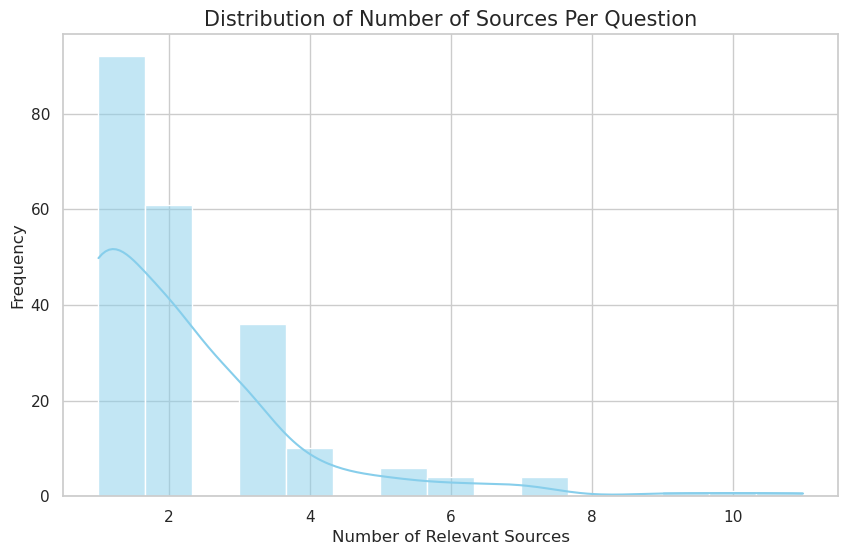

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set the visual style
sns.set_theme(style="whitegrid")

# 2. Create the plot
# kde=True adds a smooth curve over the bars
plt.figure(figsize=(10, 6))
plot = sns.histplot(data=filtered_df, x='relevant_sources_length', kde=True, color='skyblue')

# 3. Add labels and title
plt.title('Distribution of Number of Sources Per Question', fontsize=15)
plt.xlabel('Number of Relevant Sources', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()

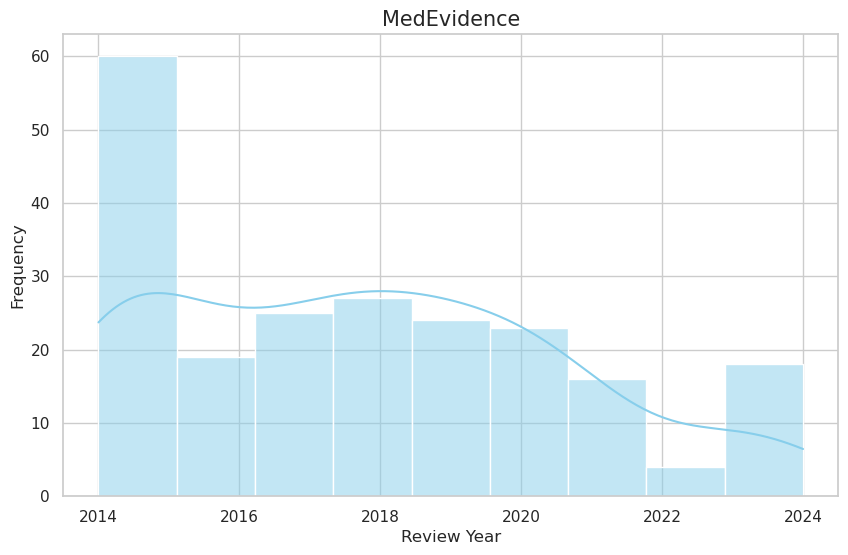

In [74]:
plt.figure(figsize=(10, 6))
plot = sns.histplot(data=filtered_df, x='review_year', kde=True, color='skyblue')

# 3. Add labels and title
plt.title('MedEvidence', fontsize=15)
plt.xlabel('Review Year', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()

In [55]:
questions_df = pd.read_json("../code/outputs/questions/qwen3_thinking-4B/cochrane_review_data_final_with_questions.json")



In [56]:
questions_df.head()

,DOI,ReviewID,ReviewTitle,ReviewAbstract,Inputs,NumInputs,Year,Keywords,NumIncludedStudies,ExtractedText,Questions,MedReadMeScores
0,10.1002/14651858.CD002818.pub2,CD002818,Amantadine for fatigue in multiple sclerosis,"[{'heading': 'Background', 'text': 'Fatigue is...","[{'ReviewID': 'CD002818', 'PMID': 14759641, 'T...",5,2007,"Amantadine [adverse effects, *therapeutic use]...",5,"{'intervention': 'amantadine', 'condition': 'f...",{'effectiveness1': {'positive_question': 'How ...,{'effectiveness1': {'positive_question': 4.524...
1,10.1002/14651858.CD008234.pub2,CD008234,Intratympanic gentamicin for Ménière's disease...,"[{'heading': 'Background', 'text': 'Ménière's ...","[{'ReviewID': 'CD008234', 'PMID': 15072419, 'T...",2,2011,Anti-Bacterial Agents [*administration & dosag...,2,"{'intervention': 'intratympanic gentamicin', '...",{'effectiveness1': {'positive_question': 'How ...,{'effectiveness1': {'positive_question': 4.982...
2,10.1002/14651858.CD008341,CD008341,Golimumab for rheumatoid arthritis,"[{'heading': 'Background', 'text': 'Golimumab ...","[{'ReviewID': 'CD008341', 'PMID': 18383539, 'T...",4,2010,"Adult; Antibodies, Monoclonal [*therapeutic us...",4,"{'intervention': 'golimumab', 'condition': 'rh...",{'effectiveness1': {'positive_question': 'How ...,{'effectiveness1': {'positive_question': 4.672...
3,10.1002/14651858.CD003685.pub2,CD003685,Rofecoxib for rheumatoid arthritis,"[{'heading': 'Background', 'text': 'Editor's n...","[{'ReviewID': 'CD003685', 'PMID': 10566565, 'T...",2,2005,"Anti‐Inflammatory Agents, Non‐Steroidal [adver...",2,"{'intervention': 'rofecoxib', 'condition': 'rh...",{'effectiveness1': {'positive_question': 'How ...,{'effectiveness1': {'positive_question': 4.667...
4,10.1002/14651858.CD007045.pub2,CD007045,Selective internal radiation therapy for liver...,"[{'heading': 'Background', 'text': 'Liver meta...","[{'ReviewID': 'CD007045', 'PMID': 11843249, 'T...",2,2009,*Colorectal Neoplasms; *Liver Neoplasms [drug ...,2,{'intervention': 'selective internal radiation...,{'effectiveness1': {'positive_question': 'How ...,{'effectiveness1': {'positive_question': 4.774...


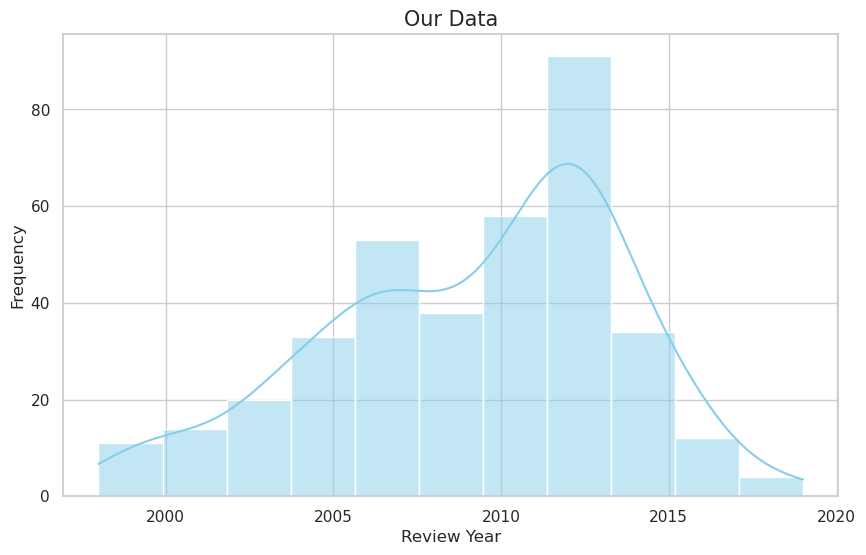

In [73]:
plt.figure(figsize=(10, 6))
plot = sns.histplot(data=questions_df, x='Year', kde=True, color='skyblue')

# 3. Add labels and title
plt.title('Our Data', fontsize=15)
plt.xlabel('Review Year', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()

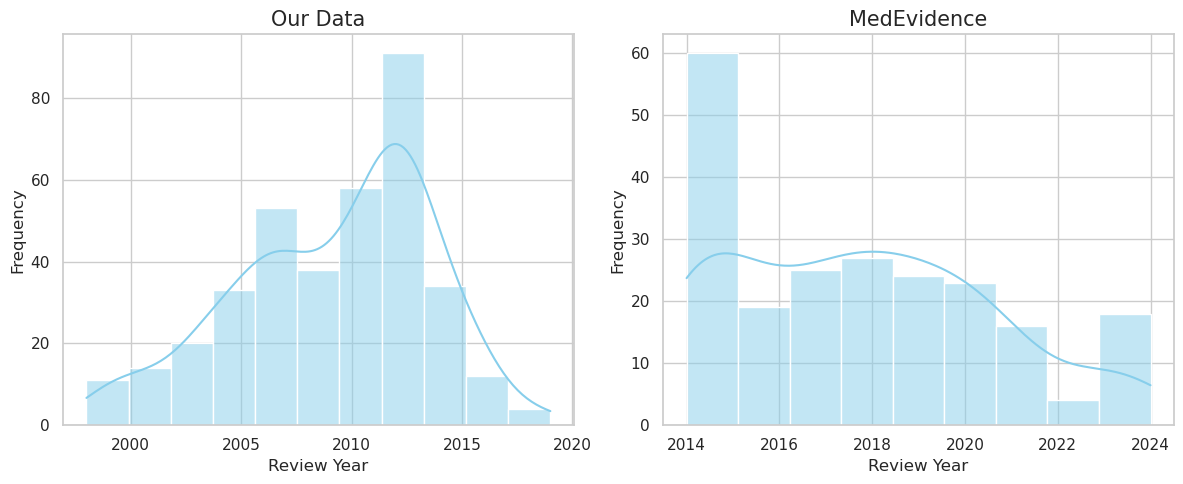

In [77]:
# two plots side-by-side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

sns.histplot(data=questions_df, x='Year', kde=True, color='skyblue', ax=axes[0])
axes[0].set_title("Our Data", fontsize=15)
axes[0].set_xlabel('Review Year', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

sns.histplot(data=filtered_df, x='review_year', kde=True, color='skyblue', ax=axes[1])
axes[1].set_title("MedEvidence", fontsize=15) 
axes[1].set_xlabel('Review Year', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

# Adjust layout for better spacing (optional)
plt.tight_layout()

# Show the plots
plt.show()

In [58]:
import requests

def convert_dois_to_pmids(doi_list, email="yun.hy@northeastern.edu"):
    """
    Converts a list of DOIs to PMIDs using the PMC ID Converter API.
    """
    base_url = "https://pmc.ncbi.nlm.nih.gov/tools/idconv/api/v1/articles/"
    
    # The API accepts comma-separated IDs (max 200 per request)
    ids_param = ",".join(doi_list)
    
    params = {
        "email": email,
        "ids": ids_param,
        "format": "json"  # You can also use 'xml' or 'csv'
    }
    
    try:
        response = requests.get(base_url, params=params)
        response.raise_for_status()
        data = response.json()
        
        # Mapping DOI to PMID
        results = {}
        for record in data.get("records", []):
            doi = record.get("doi")
            pmid = record.get("pmid")
            results[doi] = pmid
            
        return results

    except requests.exceptions.RequestException as e:
        print(f"Error connecting to API: {e}")
        return None

In [59]:
doi_list = questions_df['DOI'].tolist()

In [60]:
batches = [doi_list[i:i + 200] for i in range(0, len(doi_list), 200)]
doi_to_pmid = {}
for batch in batches:
    results = convert_dois_to_pmids(batch)
    doi_to_pmid = doi_to_pmid | results

In [61]:
len(doi_to_pmid)

368

In [62]:
questions_df['PMID'] = questions_df['DOI'].map(doi_to_pmid)

In [63]:
questions_df.head()

,DOI,ReviewID,ReviewTitle,ReviewAbstract,Inputs,NumInputs,Year,Keywords,NumIncludedStudies,ExtractedText,Questions,MedReadMeScores,PMID
0,10.1002/14651858.CD002818.pub2,CD002818,Amantadine for fatigue in multiple sclerosis,"[{'heading': 'Background', 'text': 'Fatigue is...","[{'ReviewID': 'CD002818', 'PMID': 14759641, 'T...",5,2007,"Amantadine [adverse effects, *therapeutic use]...",5,"{'intervention': 'amantadine', 'condition': 'f...",{'effectiveness1': {'positive_question': 'How ...,{'effectiveness1': {'positive_question': 4.524...,17253480.0
1,10.1002/14651858.CD008234.pub2,CD008234,Intratympanic gentamicin for Ménière's disease...,"[{'heading': 'Background', 'text': 'Ménière's ...","[{'ReviewID': 'CD008234', 'PMID': 15072419, 'T...",2,2011,Anti-Bacterial Agents [*administration & dosag...,2,"{'intervention': 'intratympanic gentamicin', '...",{'effectiveness1': {'positive_question': 'How ...,{'effectiveness1': {'positive_question': 4.982...,NaN
2,10.1002/14651858.CD008341,CD008341,Golimumab for rheumatoid arthritis,"[{'heading': 'Background', 'text': 'Golimumab ...","[{'ReviewID': 'CD008341', 'PMID': 18383539, 'T...",4,2010,"Adult; Antibodies, Monoclonal [*therapeutic us...",4,"{'intervention': 'golimumab', 'condition': 'rh...",{'effectiveness1': {'positive_question': 'How ...,{'effectiveness1': {'positive_question': 4.672...,20091667.0
3,10.1002/14651858.CD003685.pub2,CD003685,Rofecoxib for rheumatoid arthritis,"[{'heading': 'Background', 'text': 'Editor's n...","[{'ReviewID': 'CD003685', 'PMID': 10566565, 'T...",2,2005,"Anti‐Inflammatory Agents, Non‐Steroidal [adver...",2,"{'intervention': 'rofecoxib', 'condition': 'rh...",{'effectiveness1': {'positive_question': 'How ...,{'effectiveness1': {'positive_question': 4.667...,15674912.0
4,10.1002/14651858.CD007045.pub2,CD007045,Selective internal radiation therapy for liver...,"[{'heading': 'Background', 'text': 'Liver meta...","[{'ReviewID': 'CD007045', 'PMID': 11843249, 'T...",2,2009,*Colorectal Neoplasms; *Liver Neoplasms [drug ...,2,{'intervention': 'selective internal radiation...,{'effectiveness1': {'positive_question': 'How ...,{'effectiveness1': {'positive_question': 4.774...,19821394.0


In [70]:
union_df = pd.merge(df, questions_df, left_on='original_review', right_on='PMID', how='inner')

print(f"Number of matches found: {len(union_df)}")

Number of matches found: 3


In [71]:
union_df

,question_id,question,answer,evidence_certainty,fulltext_required,relevant_sources,original_review,review_year,sources,source_concordance,...,ReviewAbstract,Inputs,NumInputs,Year,Keywords,NumIncludedStudies,ExtractedText,Questions,MedReadMeScores,PMID
0,49,"Is the incidence of pneumonia higher, lower, o...",lower,low,no,"['9651405', '12052800', '16168782', '17593956']",27915460,2016,"{'9651405': {'article_id': '9651405', 'content...",0.5,...,"[{'heading': 'Background', 'text': 'Pneumonia ...","[{'ReviewID': 'CD005978', 'PMID': 17593956, 'T...",6,2016,"Child, Preschool; Gluconates [administration &...",6,"{'intervention': 'zinc supplementation', 'cond...",{'effectiveness1': {'positive_question': 'How ...,{'effectiveness1': {'positive_question': 4.177...,27915460.0
1,158,"Is pain relief higher, lower, or the same when...",higher,high,no,"['15333415', '21188849', '15100590', '15220011...",24809657,2014,"{'15333415': {'article_id': '15333415', 'conte...",1.0,...,"[{'heading': 'Background', 'text': 'This is an...","[{'ReviewID': 'CD004309', 'PMID': 15100590, 'T...",6,2014,"Acute Pain [*drug therapy]; Administration, Or...",6,{'intervention': 'single dose oral etoricoxib'...,{'effectiveness1': {'positive_question': 'How ...,{'effectiveness1': {'positive_question': 4.746...,24809657.0
2,268,Is points on disability scale mprovement highe...,higher,NaN,no,['8813270'],26305459,2015,"{'8813270': {'article_id': '8813270', 'content...",1.0,...,"[{'heading': 'Background', 'text': 'Chronic in...","[{'ReviewID': 'CD003906', 'PMID': 8813270, 'Ti...",2,2015,*Plasma Exchange; Cross‐Over Studies; Humans; ...,2,"{'intervention': 'plasma exchange', 'condition...",{'effectiveness1': {'positive_question': 'How ...,{'effectiveness1': {'positive_question': 5.106...,26305459.0


In [72]:
union_df['ReviewID']

0    CD005978
1    CD004309
2    CD003906
Name: ReviewID, dtype: object